In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PART A

## loading the dataset

In [99]:
df_sentiment = pd.read_csv('/kaggle/input/datasets/bubbl3ss/bitcoin-market-sentiment-feargreed/fear_greed_index.csv')
df_trader = pd.read_csv('/kaggle/input/datasets/bubbl3ss/historical-trader-data-hyperliquid/historical_data.csv')
df_trader.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [100]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [101]:
print(df_trader['Timestamp'].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


## number of rows and columns

In [102]:
tdrow = df_trader.shape[0]
tdcolumn = df_trader.shape[1]
print(f"Trader Data: {tdrow} rows, {tdcolumn} columns")


Trader Data: 211224 rows, 16 columns


In [103]:
sentrow = df_sentiment.shape[0]
sentcolumn = df_sentiment.shape[1]
print(f"Sentiment Data: {sentrow} rows, {sentcolumn} columns")

Sentiment Data: 2644 rows, 4 columns


## missing values and duplicates

In [104]:
print("Trader Data:")
print(df_trader.isnull().sum())
print("\nSentiment Data:")
print(df_sentiment.isnull().sum())

Trader Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Data:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [105]:
print(f"Trader Data Duplicates: {df_trader.duplicated().sum()}")
print(f"Sentiment Data Duplicates: {df_sentiment.duplicated().sum()}")

Trader Data Duplicates: 0
Sentiment Data Duplicates: 0


## convert timestamps and align the datasets by date

In [106]:

df_trader['date'] = pd.to_datetime(df_trader['Timestamp']).dt.date
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

In [107]:
df_trader['Timestamp'] = pd.to_datetime(df_trader['Timestamp'], unit='ms')
df_trader['Timestamp']

0        2024-10-27 03:33:20
1        2024-10-27 03:33:20
2        2024-10-27 03:33:20
3        2024-10-27 03:33:20
4        2024-10-27 03:33:20
                 ...        
211219   2025-06-15 15:06:40
211220   2025-06-15 15:06:40
211221   2025-06-15 15:06:40
211222   2025-06-15 15:06:40
211223   2025-06-15 15:06:40
Name: Timestamp, Length: 211224, dtype: datetime64[ns]

In [108]:
df_trader['Timestamp'] = pd.to_datetime(df_trader['Timestamp'], unit='ms')

## key metrics analysis

In [109]:
df_trader['is_win'] = df_trader['Closed PnL'] > 0
df_trader['is_long'] = (df_trader['Side'].str.lower() == 'long').astype(int)

In [110]:
daily_metrics = df_trader.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    num_trades=('Trade ID', 'count'),
    total_longs=('is_long', 'sum')
).reset_index()

In [111]:
daily_metrics['ls_ratio'] = daily_metrics['total_longs'] / daily_metrics['num_trades']

In [112]:
final_df = daily_metrics.drop(columns=['total_longs'])
display(final_df.head())

,date,Account,daily_pnl,win_rate,avg_trade_size,num_trades,ls_ratio
0,1970-01-01,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734,3818,0.0
1,1970-01-01,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,1653.226327,7280,0.0
2,1970-01-01,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,8893.000898,3809,0.0
3,1970-01-01,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,507.626933,13311,0.0
4,1970-01-01,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,3138.894782,3239,0.0


In [113]:
daily_metrics = pd.merge(daily_metrics, df_sentiment[['date', 'value']], on='date', how='inner')

In [114]:
daily_metrics['sentiment_type'] = pd.cut(
    daily_metrics['value'], 
    bins=[0, 45, 55, 100], 
    labels=['Fear', 'Neutral', 'Greed']
)

In [115]:
df_trader['date'] = pd.to_datetime(df_trader['Timestamp']).dt.date
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

In [145]:
df = df[df['classification'].isin(['Fear', 'Greed'])]

# PART B

## Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [119]:
df = pd.merge(df_trader, df_sentiment, on='date', how='left')

print(df[['date', 'classification']].head(10))

         date classification
0  2024-10-27          Greed
1  2024-10-27          Greed
2  2024-10-27          Greed
3  2024-10-27          Greed
4  2024-10-27          Greed
5  2024-10-27          Greed
6  2024-10-27          Greed
7  2024-10-27          Greed
8  2024-10-27          Greed
9  2024-10-27          Greed


In [120]:
df = pd.merge(df_trader, df_sentiment, on='date', how='inner')

df = df[df['classification'].isin(['Fear', 'Greed'])]

df['win'] = df['Closed PnL'] > 0

summary = df.groupby('classification').agg({
    'Closed PnL': ['sum', 'mean', 'min'],
    'win': 'mean'
})

summary.columns = ['Total PnL', 'Avg PnL', 'Worst Trade', 'Win Rate']

print(summary)

                   Total PnL    Avg PnL   Worst Trade  Win Rate
classification                                                 
Fear            6.699925e+06  50.047622  -35681.74723  0.415146
Greed           3.189617e+06  87.894859 -117990.10410  0.446471


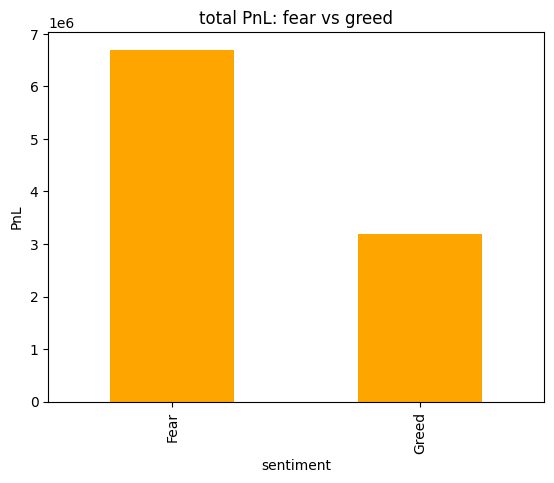

In [121]:
import matplotlib.pyplot as plt

summary['Total PnL'].plot(kind='bar', color='orange')

plt.title('total PnL: fear vs greed')
plt.xlabel('sentiment')
plt.ylabel('PnL')

plt.show()

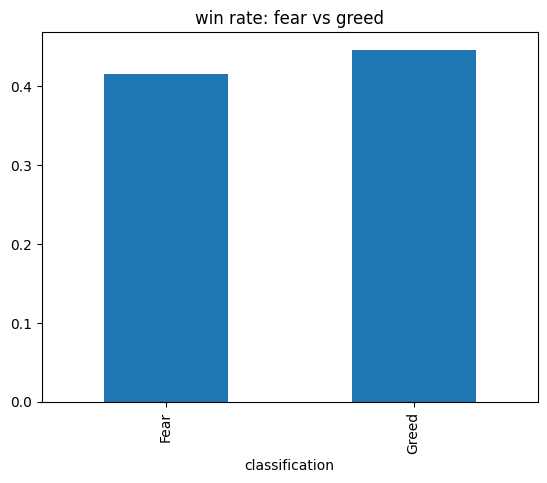

In [122]:
summary['Win Rate'].plot(kind='bar')
plt.title('win rate: fear vs greed')
plt.show()

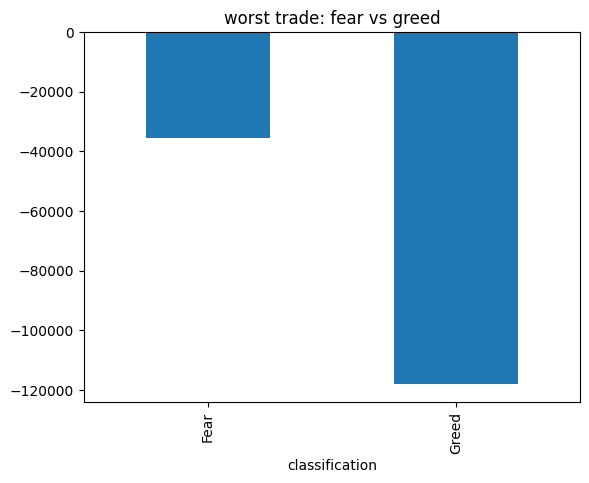

In [123]:
summary['Worst Trade'].plot(kind='bar')
plt.title('worst trade: fear vs greed')
plt.show()

## conclusion
As seen above trader performance do differ between Fear vs Greed Days.

## Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [124]:
df['classification'].unique()

array(['Greed', 'Fear'], dtype=object)

In [125]:
trade_freq = df['classification'].value_counts()
trade_freq

classification
Fear     133871
Greed     36289
Name: count, dtype: int64

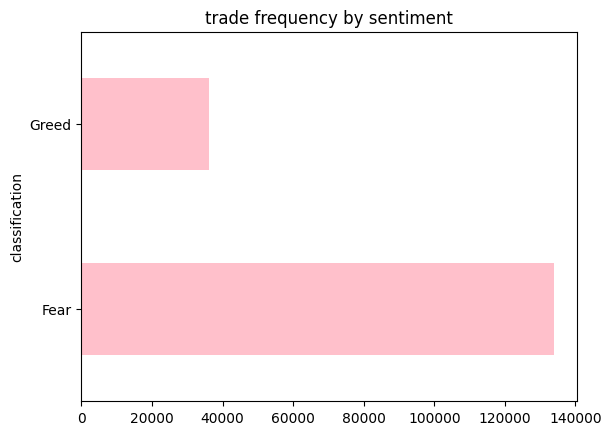

In [126]:
trade_freq.plot(kind='barh', title='trade frequency by sentiment', color='pink')
plt.show()

In [127]:
df['leverage_proxy'] = df['Size USD'] / df['Execution Price']
lev = df.groupby('classification')['leverage_proxy'].mean()
print(lev)

classification
Fear     3071.523300
Greed    2232.159641
Name: leverage_proxy, dtype: float64


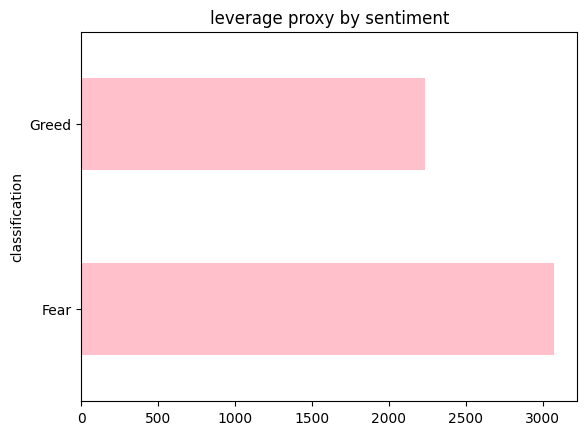

In [128]:
lev.plot(kind='barh', title='leverage proxy by sentiment', color='pink')
plt.show()

In [129]:

df['Side'] = df['Side'].astype(str).str.lower().str.strip()
df['Side']

0         buy
1         buy
2         buy
3         buy
4         buy
         ... 
184258    buy
184259    buy
184260    buy
184261    buy
184262    buy
Name: Side, Length: 170160, dtype: object

In [130]:
bias = df.groupby(['classification', 'Side']).size().unstack()
print(bias)

Side              buy   sell
classification              
Fear            66081  67790
Greed           15421  20868


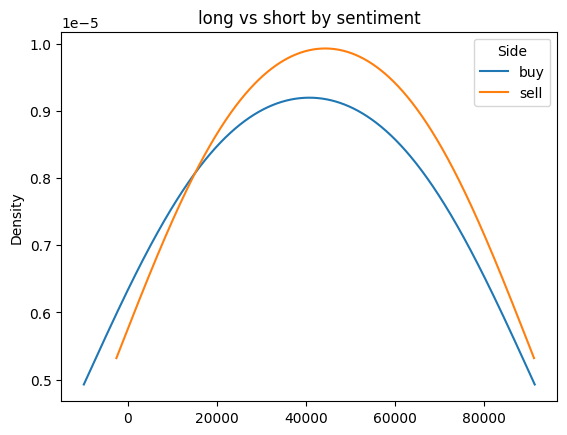

In [131]:
bias.plot(kind='kde', stacked=True, title='long vs short by sentiment')
plt.show()

In [132]:
pos = df.groupby('classification')['Size USD'].mean()
pos

classification
Fear     5259.977837
Greed    3182.883845
Name: Size USD, dtype: float64

<Axes: title={'center': 'avg position size by sentiment'}, xlabel='classification'>

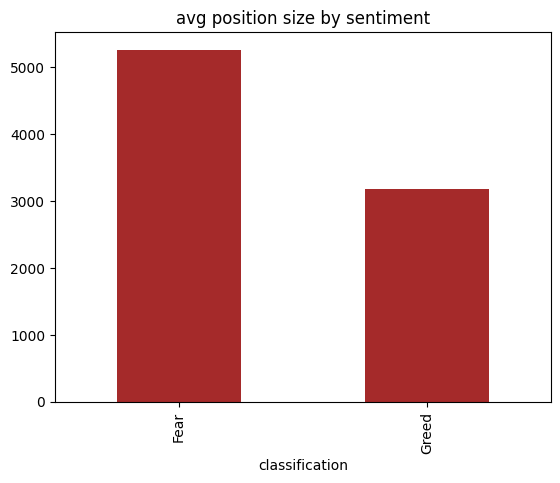

In [133]:
pos.plot(kind='bar', title='avg position size by sentiment', color='brown')

# conclusion
Trader behaviour depends largely upon sentiment. There are more trades during Fear than in Greed as during fear market drops low. During Greed, traders take larger positions or higher leverages. During Fear, traders trade or invest more cautiously, with position sizes. The noticeable shift in long vs short bias reflects how sentiment directly influences market direction expectations.

In [146]:

trader_profiles = df_trader.groupby('Account').agg(
    total_trades=('Trade ID', 'count'),
    avg_size=('Size USD', 'mean'),
    win_rate=('is_win', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reset_index()



In [147]:
median_trades = trader_profiles['total_trades'].median()
trader_profiles['activity_segment'] = trader_profiles['total_trades'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

In [ ]:
median_size = trader_profiles['avg_size'].median()
trader_profiles['leverage_segment'] = trader_profiles['avg_size'].apply(
    lambda x: 'High Size' if x > median_size else 'Low Size'
)

In [137]:
trader_profiles['consistency_segment'] = trader_profiles['win_rate'].apply(
    lambda x: 'Consistent' if x >= 0.50 else 'Inconsistent'
)

## frquency vs profitability

In [139]:

insight1 = trader_profiles.groupby('activity_segment').agg(
    avg_pnl=('total_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean')
)
insight1

,avg_pnl,avg_win_rate
activity_segment,,
Frequent,496527.661215,0.413562
Infrequent,147032.272750,0.392563


## the size risk

In [143]:
df_merged = pd.merge(
    df_trader, 
    df_sentiment[['date', 'value', 'classification']], 
    left_on='date', 
    right_on='date', 
    how='inner'
)

In [149]:
trader_win_rates = df_merged.groupby('Account')['is_win'].mean()

df_merged['consistency_segment'] = df_merged['Account'].map(
    lambda x: 'Consistent' if trader_win_rates[x] >= 0.5 else 'Inconsistent'
)

In [153]:
insight2 = df_merged.groupby(['consistency_segment', 'classification'], observed=False).agg(
    avg_pnl=('Closed PnL', 'mean')
).unstack()
insight2

avg_pnl                                   
classification      Extreme Greed       Fear       Greed     Neutral
consistency_segment                                                 
Consistent              60.032625  47.106617  151.112982  445.775869
Inconsistent            -2.837619  50.237578   84.001981    4.043270

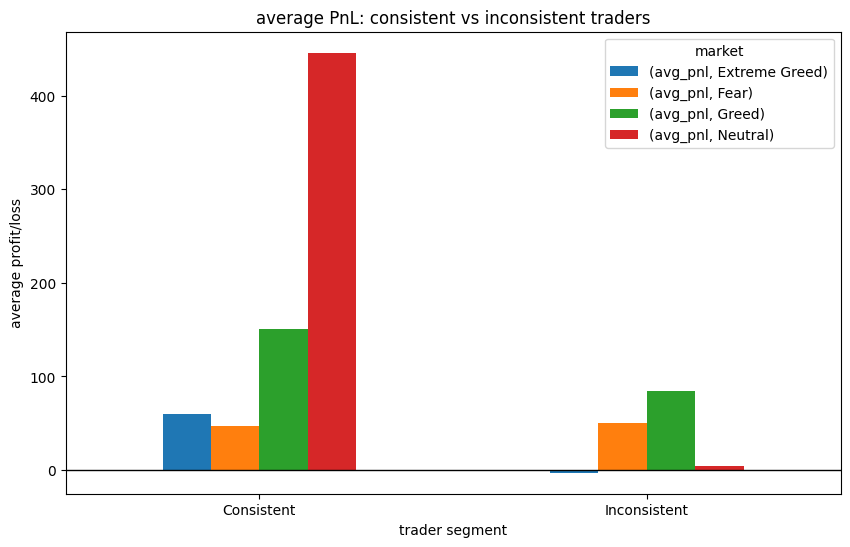

In [154]:
import matplotlib.pyplot as plt

insight3.plot(kind='bar', figsize=(10, 6))
plt.title('average PnL: consistent vs inconsistent traders')
plt.ylabel('average profit/loss')
plt.xlabel('trader segment')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=1)
plt.legend(title='market')
plt.show()

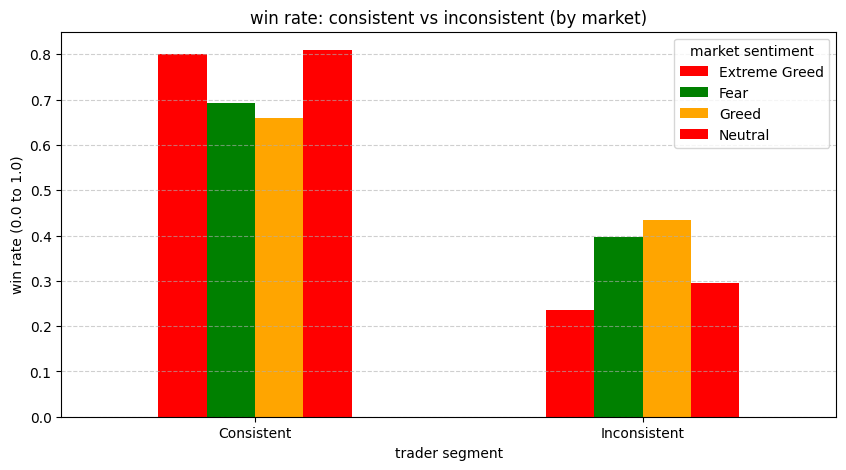

In [155]:

wr_chart = df_merged.groupby(['consistency_segment', 'classification'], observed=False)['is_win'].mean().unstack()

wr_chart.plot(kind='bar', figsize=(10, 5), color=['red', 'green', 'orange'])
plt.title('win rate: consistent vs inconsistent (by market)')
plt.ylabel('win rate (0.0 to 1.0)')
plt.xlabel('trader segment')
plt.xticks(rotation=0)
plt.legend(title='market sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# PART C

## CONSISTENCY INSIGHT
Our Consistency Insight suggests that frequent traders often see a win-rate decay during Fear, likely due to over-trading in these conditions.

## LEVERAGE TRAP
High Leverage bar during Fear is deeper (more negative) than the Low Leverage bar, it shows that leverage doesn't just amplify profits. It creates "catastrophic" exit points during market panic.